In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme()
pd.set_option('display.float_format', '{:.3f}'.format)
RANDOM_STATE = 42

In [2]:
# Load train and validation sets, converting Time to datetime
train_df = pd.read_csv('../Data/train.csv')
val_df = pd.read_csv('../Data/val.csv')

train_df['Time'] = pd.to_datetime(train_df['Time'], format='mixed', errors='coerce')
val_df['Time'] = pd.to_datetime(val_df['Time'], format='mixed', errors='coerce')

print(train_df.shape)
print(val_df.shape)

(71647, 19)
(17735, 19)


In [3]:
# Explicit feature list and target column
features = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
            'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
target = 'Power[kW]'

In [4]:
# Build feature matrices and target vectors
X_train = train_df[features]
y_train = train_df[target]
X_val = val_df[features]
y_val = val_df[target]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_train.columns)

(71647, 13) (71647,)
(17735, 13) (17735,)
Index(['GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h',
       'snow_1h', 'clouds_all', 'dayLength', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos'],
      dtype='object')


In [5]:
# Regression metrics helper
def regression_report(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label}  RMSE={rmse:,.3f}  MAE={mae:,.3f}  R2={r2:.3f}')
    return rmse, mae, r2

In [6]:
# Baseline: predict the training mean for every row
baseline_pred_val = np.full(shape=y_val.shape, fill_value=y_train.mean())
baseline_rmse, baseline_mae, baseline_r2 = regression_report(y_val, baseline_pred_val, label='Baseline (mean)')

Baseline (mean)  RMSE=4.668  MAE=3.920  R2=-0.004


In [7]:
# Fit a Random Forest with fixed hyperparameters
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

train_rmse, train_mae, train_r2 = regression_report(y_train, rf.predict(X_train), label='RF train')
val_rmse, val_mae, val_r2 = regression_report(y_val, rf.predict(X_val), label='RF val')

RF train  RMSE=1.383  MAE=0.782  R2=0.922
RF val  RMSE=1.692  MAE=0.970  R2=0.868


   min_samples_leaf  train_r2  val_r2   gap
0                 1     0.988   0.866 0.122
1                 5     0.956   0.869 0.087
2                10     0.938   0.869 0.068
3                20     0.922   0.868 0.054
4                50     0.907   0.867 0.041
5               100     0.899   0.865 0.034


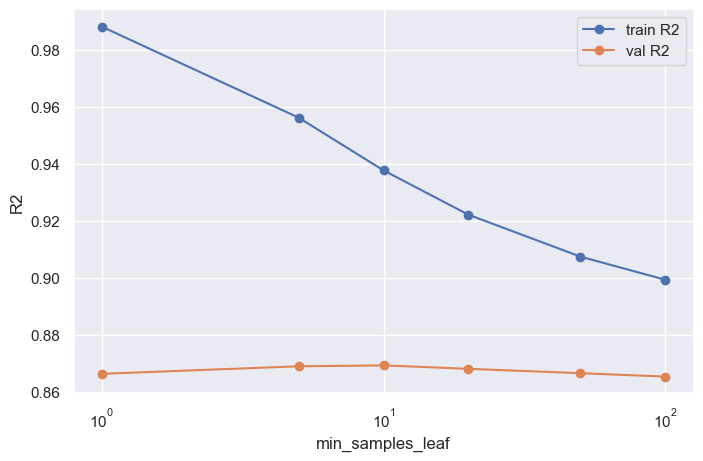

In [8]:
# Sweep min_samples_leaf to check for overfitting
leaf_values = [1, 5, 10, 20, 50, 100]
sweep_results = []
for leaf in leaf_values:
    model = RandomForestRegressor(n_estimators=200, min_samples_leaf=leaf,
                                   random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    tr_r2 = r2_score(y_train, model.predict(X_train))
    va_r2 = r2_score(y_val, model.predict(X_val))
    sweep_results.append({'min_samples_leaf': leaf, 'train_r2': tr_r2, 'val_r2': va_r2})

sweep_df = pd.DataFrame(sweep_results)
sweep_df['gap'] = sweep_df['train_r2'] - sweep_df['val_r2']
print(sweep_df)

plt.figure(figsize=(8, 5))
plt.plot(sweep_df['min_samples_leaf'], sweep_df['train_r2'], marker='o', label='train R2')
plt.plot(sweep_df['min_samples_leaf'], sweep_df['val_r2'], marker='o', label='val R2')
plt.xscale('log')
plt.xlabel('min_samples_leaf')
plt.ylabel('R2')
plt.legend()
plt.show()

       feature  importance
0          GHI       0.858
8    dayLength       0.075
9     hour_sin       0.015
10    hour_cos       0.011
7   clouds_all       0.011


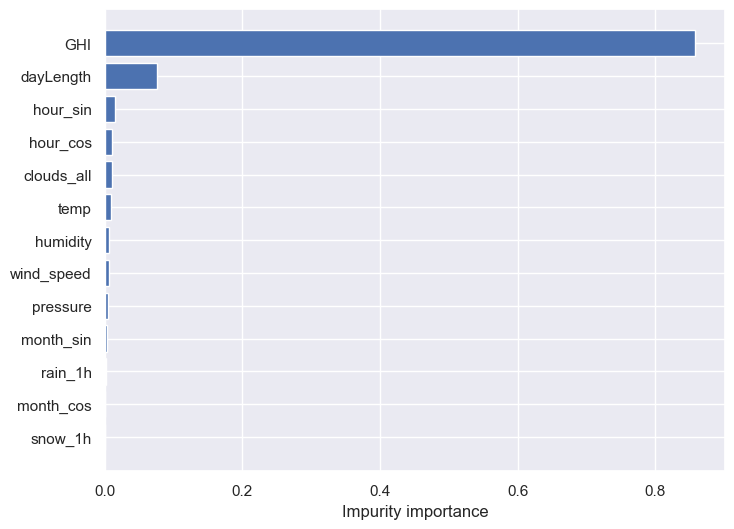

In [9]:
# Refit with the best min_samples_leaf by validation R2
best_leaf = int(sweep_df.loc[sweep_df['val_r2'].idxmax(), 'min_samples_leaf'])
rf_best = RandomForestRegressor(n_estimators=200, min_samples_leaf=best_leaf,
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_best.fit(X_train, y_train)

importance_df = pd.DataFrame({'feature': features, 'importance': rf_best.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False)
print(importance_df.head(5))

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Impurity importance')
plt.gca().invert_yaxis()
plt.show()

In [10]:
# Permutation importance on the validation set
perm_result = permutation_importance(rf_best, X_val, y_val, n_repeats=5,
                                      random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({'feature': features, 'perm_importance': perm_result.importances_mean})

impurity_imp = importance_df.set_index('feature')['importance']
perm_imp = perm_df.set_index('feature')['perm_importance'].sort_values(ascending=False)
impurity_imp = impurity_imp.sort_values(ascending=False)

compare_rows = []
for rank in range(10):
    compare_rows.append({'rank': rank + 1,
                         'impurity_feature': impurity_imp.index[rank],
                         'impurity_importance': impurity_imp.iloc[rank],
                         'perm_feature': perm_imp.index[rank],
                         'perm_importance': perm_imp.iloc[rank]})

compare_df = pd.DataFrame(compare_rows)
print(compare_df)

   rank impurity_feature  impurity_importance perm_feature  perm_importance
0     1              GHI                0.858          GHI            1.743
1     2        dayLength                0.075    dayLength            0.178
2     3         hour_sin                0.015     hour_sin            0.032
3     4         hour_cos                0.011     hour_cos            0.032
4     5       clouds_all                0.011   clouds_all            0.011
5     6             temp                0.009         temp            0.003
6     7         humidity                0.006     humidity            0.003
7     8       wind_speed                0.005      rain_1h            0.001
8     9         pressure                0.005    month_sin            0.001
9    10        month_sin                0.003     pressure            0.001


       feature  mean   std
0          GHI 0.871 0.000
8    dayLength 0.075 0.000
9     hour_sin 0.014 0.000
10    hour_cos 0.011 0.000
7   clouds_all 0.009 0.000


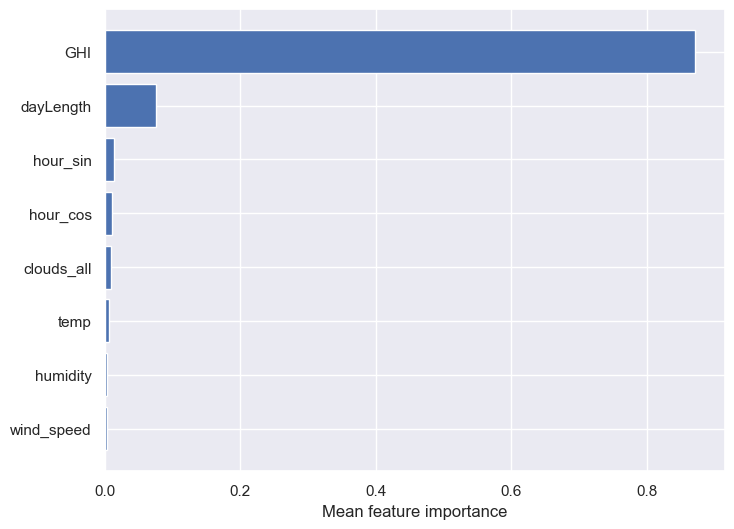

In [11]:
# Stability check across multiple random seeds
stability_seeds = [0, 1, 2, 3, 4]
stability_importances = []
for seed in stability_seeds:
    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=20,
                                   random_state=seed, n_jobs=-1)
    model.fit(X_train, y_train)
    stability_importances.append(model.feature_importances_)

stability_array = np.array(stability_importances)
stability_mean = stability_array.mean(axis=0)
stability_std = stability_array.std(axis=0)

stability_df = pd.DataFrame({'feature': features, 'mean': stability_mean, 'std': stability_std})
stability_df = stability_df.sort_values('mean', ascending=False)
print(stability_df.head(5))

top8 = stability_df.head(8)
plt.figure(figsize=(8, 6))
plt.barh(top8['feature'], top8['mean'], xerr=top8['std'])
plt.xlabel('Mean feature importance')
plt.gca().invert_yaxis()
plt.show()

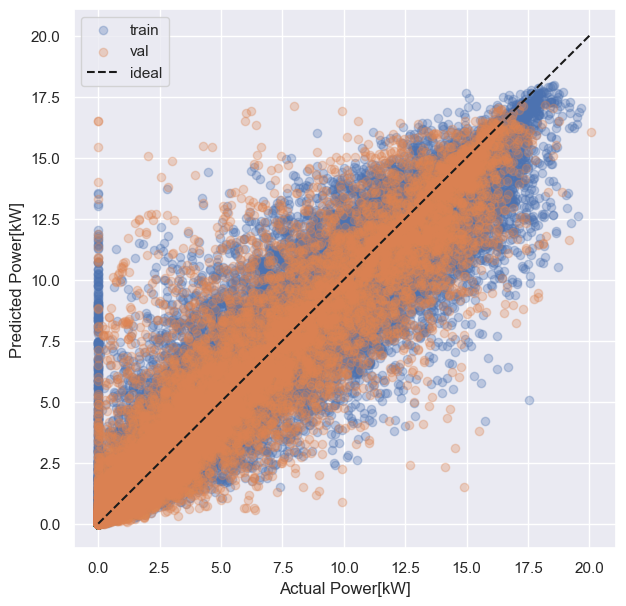

In [12]:
# Predicted vs actual scatter for train and validation
train_pred = rf_best.predict(X_train)
val_pred = rf_best.predict(X_val)

plt.figure(figsize=(7, 7))
plt.scatter(y_train, train_pred, alpha=0.3, label='train')
plt.scatter(y_val, val_pred, alpha=0.3, label='val')
lims = [min(y_train.min(), y_val.min()), max(y_train.max(), y_val.max())]
plt.plot(lims, lims, 'k--', label='ideal')
plt.xlabel('Actual Power[kW]')
plt.ylabel('Predicted Power[kW]')
plt.legend()
plt.show()

In [13]:
# Final validation metrics summary
final_val_rmse, final_val_mae, final_val_r2 = regression_report(y_val, rf_best.predict(X_val), label='RF best val')
final_metrics = pd.DataFrame([{
    'model': 'RandomForest',
    'min_samples_leaf': best_leaf,
    'RMSE': final_val_rmse,
    'MAE': final_val_mae,
    'R2': final_val_r2
}])
print(final_metrics)

RF best val  RMSE=1.684  MAE=0.966  R2=0.869
          model  min_samples_leaf  RMSE   MAE    R2
0  RandomForest                10 1.684 0.966 0.869


In [16]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression().fit(X_train, y_train)
lr_val_pred = lr.predict(X_val)

rmse, mae, r2 = regression_report(y_val, lr_val_pred, label='Linear Regression ')


Linear Regression   RMSE=2.109  MAE=1.543  R2=0.795


In [20]:
rmse, mae, r2 = regression_report(y_val, lr_val_pred, label='Linear Regression ')
final_val_rmse, final_val_mae, final_val_r2 = regression_report(y_val, rf_best.predict(X_val), label='Random Forest best val')


Linear Regression   RMSE=2.109  MAE=1.543  R2=0.795
Random Forest best val  RMSE=1.684  MAE=0.966  R2=0.869


Random Forest outperformed Linear Regression across all three evaluation metrics.

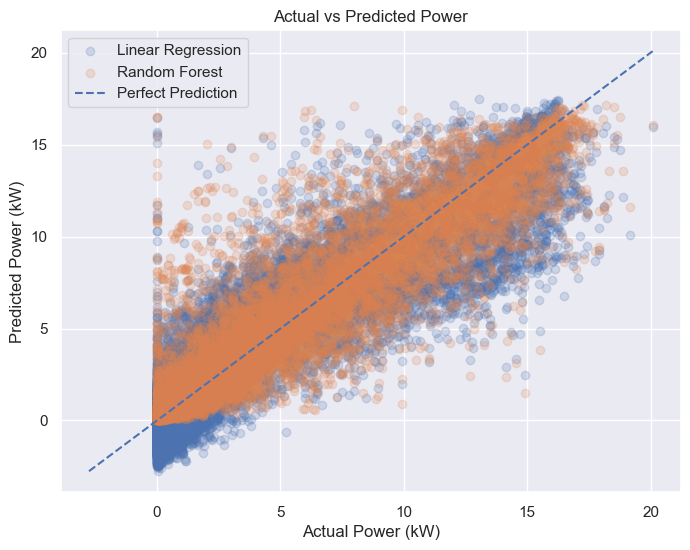

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(y_val, lr_val_pred, alpha=0.2, label='Linear Regression')
plt.scatter(y_val, val_pred, alpha=0.2, label='Random Forest')

min_val = min(y_val.min(), lr_val_pred.min(), val_pred.min())
max_val = max(y_val.max(), lr_val_pred.max(), val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('Actual vs Predicted Power')
plt.legend()
plt.show()